In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
from Suspension.hardpoint_loader import load_suspension_params
from Suspension.jax_solvers import solve_and_measure_corner
from Suspension.jax_solvers import solve_corner_jax
from Suspension.visualizer import SuspensionVisualizer
import pyvista as pv
import nest_asyncio
nest_asyncio.apply()
pv.set_jupyter_backend('trame')

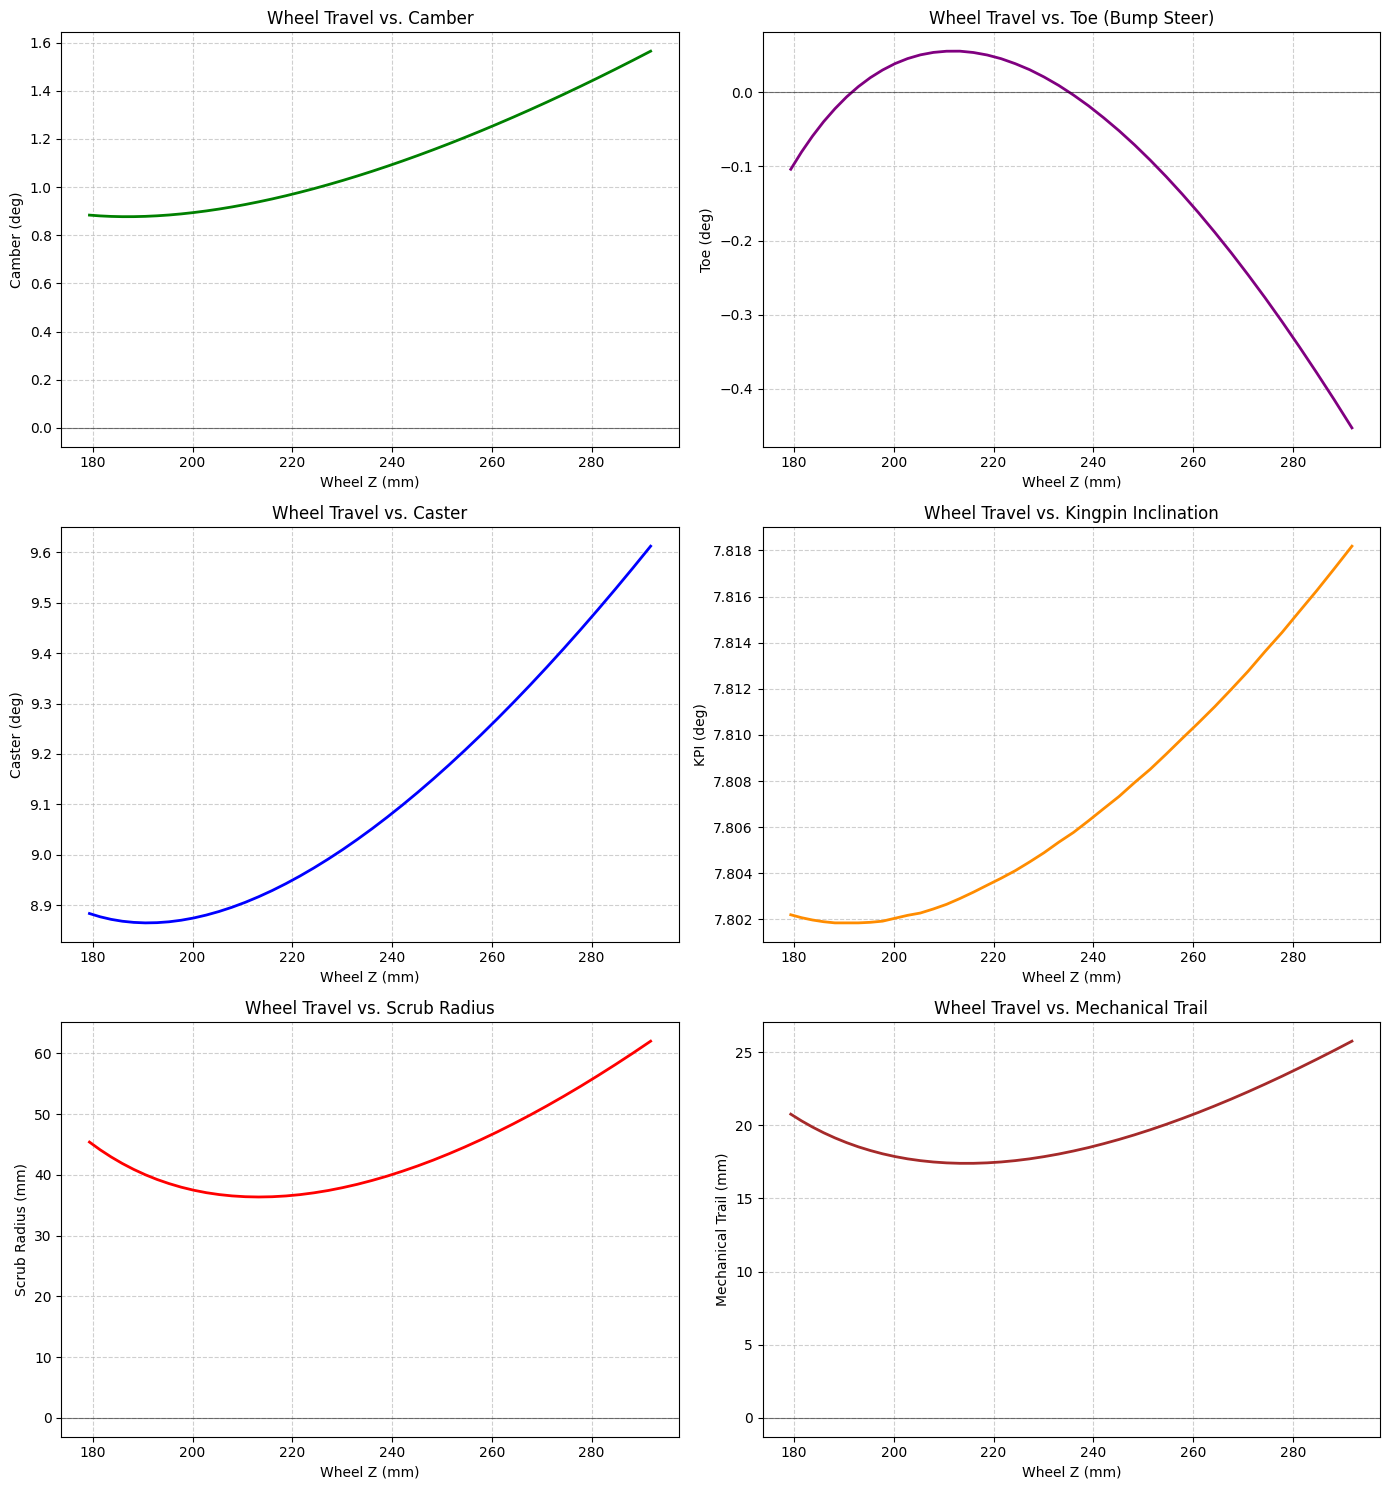

In [2]:
# 1. Setup Parameters
corner_name = "front_right"
params = load_suspension_params("hardpoints.yaml", corner_name)

# 2. Define the Range of Motion
thetas = jnp.radians(jnp.linspace(-10, 10, 40)) 
fixed_steer = 0.0

# 3. Initialize storage for results
travel_mm = []
caster_deg = []
scrub_mm = []
camber_deg = []
toe_deg = []
kpi_deg = []          # New: Kingpin Inclination
mech_trail_mm = []    # New: Mechanical Trail

# 4. Run the Sweep Loop
for t in thetas:
    metrics = solve_and_measure_corner(t, fixed_steer, params)
    
    # Store the values (converting to readable units)
    travel_mm.append(metrics["wheel_z"] * 1000)
    caster_deg.append(jnp.degrees(metrics["caster"]))
    scrub_mm.append(metrics["scrub_radius"] * 1000)
    camber_deg.append(jnp.degrees(metrics["camber"]))
    toe_deg.append(jnp.degrees(metrics["toe"]))
    kpi_deg.append(jnp.degrees(metrics["kingpin_inc"]))
    mech_trail_mm.append(metrics["mechanical_trail"] * 1000)

# 5. Plotting (Expanded to 3x2 Grid)
plt.figure(figsize=(14, 15))

# Plot 1: Camber Curve
plt.subplot(3, 2, 1)
plt.plot(travel_mm, camber_deg, color='green', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Camber")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Camber (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Bump Steer (Toe)
plt.subplot(3, 2, 2)
plt.plot(travel_mm, toe_deg, color='purple', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Toe (Bump Steer)")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Toe (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Caster
plt.subplot(3, 2, 3)
plt.plot(travel_mm, caster_deg, color='blue', linewidth=2)
plt.title("Wheel Travel vs. Caster")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Caster (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Kingpin Inclination (KPI/SAI)
plt.subplot(3, 2, 4)
plt.plot(travel_mm, kpi_deg, color='darkorange', linewidth=2)
plt.title("Wheel Travel vs. Kingpin Inclination")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("KPI (deg)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 5: Scrub Radius
plt.subplot(3, 2, 5)
plt.plot(travel_mm, scrub_mm, color='red', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Scrub Radius")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Scrub Radius (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 6: Mechanical Trail
plt.subplot(3, 2, 6)
plt.plot(travel_mm, mech_trail_mm, color='brown', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.title("Wheel Travel vs. Mechanical Trail")
plt.xlabel("Wheel Z (mm)")
plt.ylabel("Mechanical Trail (mm)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

/var/folders/yy/pf4q99nj3xz08nmtxj05kndr0000gn/T/ipykernel_30388/403008911.py:25: UserWarning: Failed to use notebook backend: 

Please install `nest_asyncio2` to automagically launch the trame server without await. Or, to avoid `nest_asyncio2` run:

from pyvista.trame.jupyter import launch_server
await launch_server().ready

Falling back to a static output.
  viz.plotter.show()


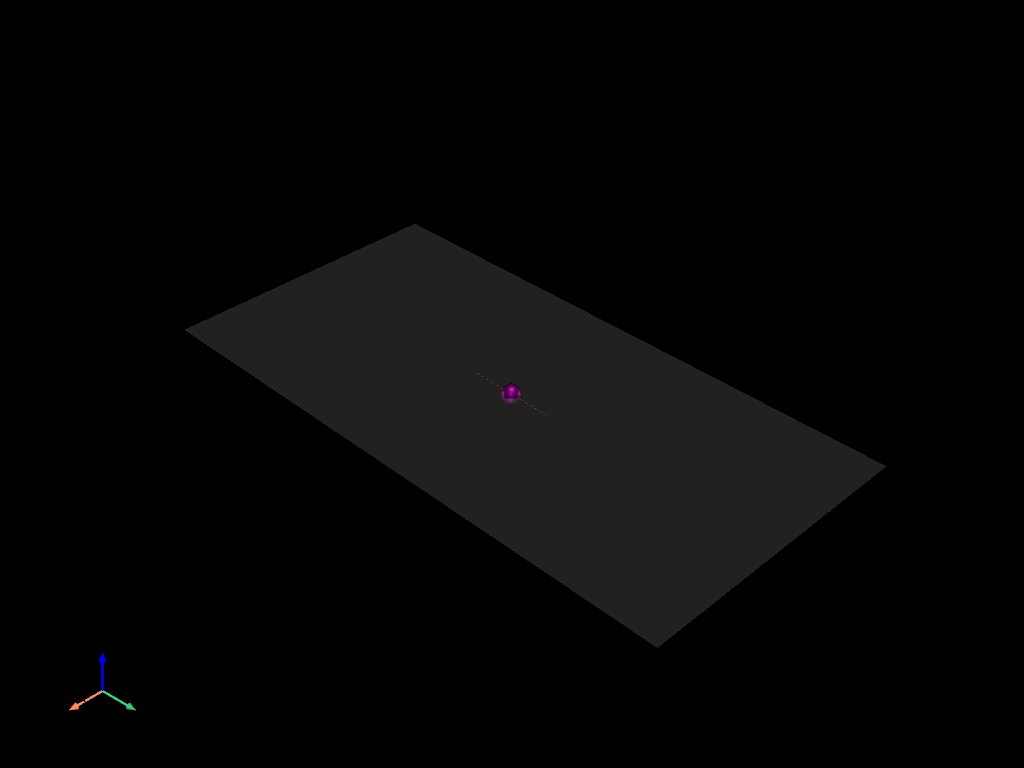

In [3]:
# 1. Setup the parameters (from your existing logic)
corner_name = "front_right"
params = load_suspension_params("hardpoints.yaml", corner_name)

# 2. Initialize the visualizer class from your file
viz = SuspensionVisualizer(params)

# 3. Build the initial static environment
viz.add_ground_plane()
viz.add_chassis_points()

# 4. Get the starting state from your solver
initial_state = solve_corner_jax(0.0, 0.0, params)

# 5. Setup the moving parts
viz.setup_a_arms(params["u_origin"], params["u_axis"], "royalblue", "u_arm")
viz.setup_a_arms(params["l_origin"], params["l_axis"], "firebrick", "l_arm")
viz.setup_hardpoints(initial_state["upper_bj"], "UBJ")
viz.setup_hardpoints(initial_state["lower_bj"], "LBJ")
viz.setup_hardpoints(initial_state["toe_link"], "TOE")
viz.setup_tie_rod(params["rack_origin"], initial_state["toe_link"], "tie_rod")
viz.setup_wheel_disc(initial_state["wheel_center"], initial_state["axle_dir"], params["wheel_radius"], 150, "wheel")

# 6. Preview the static scene in the notebook
viz.plotter.show()